<a href="https://colab.research.google.com/github/Kunal0110/mini_projects_ML/blob/main/ml/weekly_projects/week-4/Logistic_Regression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [38]:
import pandas as pd

titanic_data = pd.read_csv("/content/sample_data/train.csv")

In [39]:
titanic_data.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


#Splitting the data

In [45]:
X = titanic_data.drop(['PassengerId', 'Survived', 'Name', 'Ticket', 'Cabin'], axis=1)
y = titanic_data['Survived']
print(X.head())

   Pclass     Sex   Age  SibSp  Parch     Fare Embarked
0       3    male  22.0      1      0   7.2500        S
1       1  female  38.0      1      0  71.2833        C
2       3  female  26.0      0      0   7.9250        S
3       1  female  35.0      1      0  53.1000        S
4       3    male  35.0      0      0   8.0500        S


In [46]:
from sklearn.model_selection import train_test_split, cross_val_score

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42)

#Handle missing values in Age and Embarked

In [47]:
median_age = X_train['Age'].median()
mode_series = X_train['Embarked'].dropna().mode()
mode = mode_series.iat[0] if not mode_series.empty else 'S'

#Tidying test and train so that there is no leakage

In [48]:
def tidy_data(df):
  df = df.copy()
  df['Age'] = df['Age'].fillna(median_age)
  df['Embarked'] = df['Embarked'].fillna(mode)
  df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})
  df = pd.get_dummies(df, columns=['Embarked'], drop_first=True)

  return df

X_train = tidy_data(X_train)
X_test = tidy_data(X_test)

X_test = X_test.reindex(columns=X_train.columns, fill_value=0)

#Logistic Regression

In [49]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, roc_curve
from sklearn.preprocessing import StandardScaler

logreg = LogisticRegression(penalty='l2', C=1.0, max_iter=1000)
logreg.fit(X_train, y_train)

#Make predictions

y_pred_test = logreg.predict(X_test)
y_pred_prob_test = logreg.predict_proba(X_test)[:,1]

#Evaluate the model

In [50]:
accuracy_logreg = accuracy_score(y_test, y_pred_test)
roc_auc_logreg = roc_auc_score(y_test, y_pred_prob_test)

print(f"Accuracy (Logistic Regression): {accuracy_logreg}")
print(f"ROC AUC (Logistic Regression): {roc_auc_logreg}")

Accuracy (Logistic Regression): 0.8071748878923767
ROC AUC (Logistic Regression): 0.8779976521884957


#Plot ROC curve

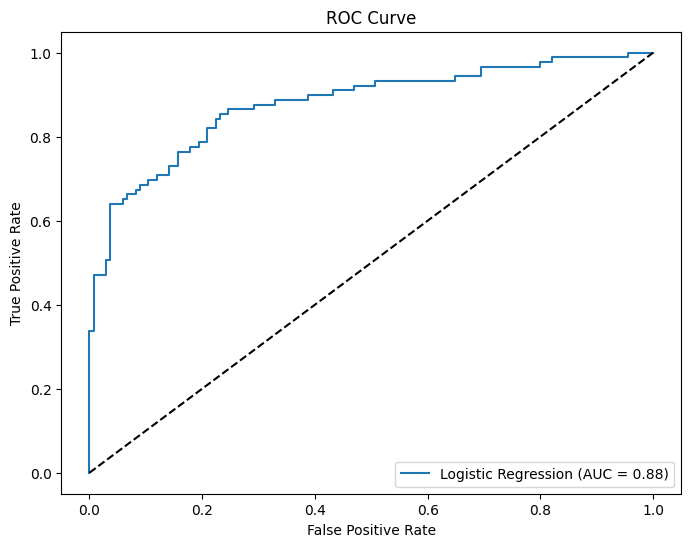

In [51]:
import matplotlib.pyplot as plt
fpr, tpr, _ = roc_curve(y_test, y_pred_prob_test)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {roc_auc_logreg:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.show()

#Training and comparing a decision Tree Model

In [52]:
from sklearn.tree import DecisionTreeClassifier

d_tree = DecisionTreeClassifier(random_state=42)
d_tree.fit(X_train, y_train)

y_pred_test_d_tree = d_tree.predict(X_test)
y_pred_prob_test_d_tree = d_tree.predict_proba(X_test)[:,1]

#Evaluate the model

In [53]:
accuracy_tree = accuracy_score(y_test, y_pred_test_d_tree)
auc_tree = roc_auc_score(y_test, y_pred_prob_test_d_tree)

print(f"Accuracy (Decision Tree): {accuracy_tree}")
print(f"ROC AUC (Decision Tree): {auc_tree}")

Accuracy (Decision Tree): 0.7443946188340808
ROC AUC (Decision Tree): 0.7311755827603555


#Observing overfitting in a deep decision tree

In [54]:
deep_tree = DecisionTreeClassifier(random_state=42)
deep_tree.fit(X_train, y_train)

#Evaluate on training data
y_pred_train_deep_tree = deep_tree.predict(X_train)
accuracy_train_deep = accuracy_score(y_train, y_pred_train_deep_tree)

#Evaluate on validation data
y_pred_test_deep_tree = deep_tree.predict(X_test)
accuracy_test_deep = accuracy_score(y_test, y_pred_test_deep_tree)

print(f"Accuracy (Deep Decision Tree on Validation Data): {accuracy_test_deep}")
print(f"Accuracy (Deep Decision Tree on Training Data): {accuracy_train_deep}")

Accuracy (Deep Decision Tree on Validation Data): 0.7443946188340808
Accuracy (Deep Decision Tree on Training Data): 0.9805389221556886


#Mitigating Overfitting by Tree Pruning

In [62]:
pruned_tree = DecisionTreeClassifier(max_depth=3, random_state=42)
pruned_tree.fit(X_train, y_train)

#Evaluate on training data
y_pred_train_pruned_tree = pruned_tree.predict(X_train)
accuracy_train_pruned = accuracy_score(y_train, y_pred_train_pruned_tree)

#Evaluate on validation data
y_pred_test_pruned_tree = pruned_tree.predict(X_test)
accuracy_test_pruned = accuracy_score(y_test, y_pred_test_pruned_tree)

print(f"Accuracy (Pruned Decision Tree on Validation Data): {accuracy_test_pruned}")
print(f"Accuracy (Pruned Decision Tree on Training Data): {accuracy_train_pruned}")

Accuracy (Pruned Decision Tree on Validation Data): 0.8026905829596412
Accuracy (Pruned Decision Tree on Training Data): 0.8323353293413174
